# Session 8 supplement: Pricing derivatives with QuantLib

Your main notebook builds Black-Scholes, the binomial tree and implied volatility from scratch with
NumPy and SciPy. That is the right way to *learn* the mechanics. This notebook shows the other side:
how a professional library does the same job in a few lines, and then goes past what the closed form
can do (American exercise, dividends, exotics).

**QuantLib** is the open-source C++ library that sits behind a lot of real pricing and risk systems;
`QuantLib-Python` is the Python wrapper. It is verbose but powerful. The whole library follows one
pattern, and once you see it everything else is variations:

> **quote  ->  handle  ->  term structures  ->  process  ->  engine  ->  NPV and Greeks**

We ground every example in real SPY data so the numbers are recognisable.

Install (once): `pip install QuantLib`

In [1]:
import QuantLib as ql
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})
NAVY, BLUE, GREEN, RED, GOLD, PUR = '#1a3a5c', '#2C7BB6', '#1A9641', '#D7191C', '#FDAE61', '#762A83'
print('QuantLib version:', ql.__version__)

QuantLib version: 1.43


## Load the real SPY inputs

We take the spot from the cached price history and the volatility from the trailing one-year realised
vol, so the option we price is a real, current SPY option.

In [2]:
DATA = 'notebook_data'
px = pd.read_csv(os.path.join(DATA, 'spy_prices.csv'), parse_dates=['Date'])
S0 = float(px['Close'].iloc[-1])
ret = np.log(px['Close'] / px['Close'].shift(1)).dropna()
sigma0 = float(ret.iloc[-252:].std() * np.sqrt(252))
asof = px['Date'].iloc[-1].date()
print(f'SPY spot        ${S0:,.2f}')
print(f'Realised vol    {sigma0:.1%}  (trailing 252 days)')
print(f'As of           {asof}')

SPY spot        $754.02
Realised vol    12.6%  (trailing 252 days)
As of           2026-07-15


## Part 1: The building blocks

Everything in QuantLib is dated. You set a global **evaluation date**, choose a **calendar** (which
days are trading days) and a **day-count convention** (how a gap between two dates becomes a fraction
of a year). Market numbers are wrapped in a **Quote**, and a **Handle** is a live pointer to a quote:
if the quote changes, everything built on the handle updates automatically. That observer pattern is
how QuantLib recomputes Greeks when you bump the spot.

In [3]:
today = ql.Date(asof.day, asof.month, asof.year)
ql.Settings.instance().evaluationDate = today
calendar  = ql.UnitedStates(ql.UnitedStates.NYSE)
day_count = ql.Actual365Fixed()
print('Evaluation date :', today)
print('Calendar        :', calendar.name())
print('Is today a business day? ', calendar.isBusinessDay(today))

# a quote and a live handle onto it
q = ql.SimpleQuote(S0)
h = ql.QuoteHandle(q)
print('\nhandle sees      ', h.value())
q.setValue(S0 * 1.01)                 # change the quote...
print('after bumping 1% ', h.value(), ' <- the handle updated on its own')
q.setValue(S0)

Evaluation date : July 15th, 2026
Calendar        : New York stock exchange
Is today a business day?  True

handle sees       754.02001953125
after bumping 1%  761.5602197265625  <- the handle updated on its own


## Part 2: Price a European option (Black-Scholes-Merton)

Now the full pattern. We build the four term structures the model needs (spot, risk-free curve,
dividend curve, volatility), bundle them into a **process**, attach an **analytic engine**, and read
the price and every Greek straight off the option.

In [4]:
r, div, sigma = 0.03, 0.012, sigma0          # rate, SPY dividend yield ~1.2%, vol
K = round(S0 / 5) * 5                          # nearest $5 strike (about at the money)
maturity = calendar.advance(today, ql.Period(1, ql.Years))
T = day_count.yearFraction(today, maturity)

spot_q  = ql.SimpleQuote(S0)                   # keep a handle to the spot so we can bump it later
spot_h  = ql.QuoteHandle(spot_q)
rf_ts   = ql.YieldTermStructureHandle(ql.FlatForward(today, r,   day_count))
div_ts  = ql.YieldTermStructureHandle(ql.FlatForward(today, div, day_count))
vol_ts  = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, calendar, sigma, day_count))
process = ql.BlackScholesMertonProcess(spot_h, div_ts, rf_ts, vol_ts)

payoff  = ql.PlainVanillaPayoff(ql.Option.Call, K)
euro    = ql.VanillaOption(payoff, ql.EuropeanExercise(maturity))
euro.setPricingEngine(ql.AnalyticEuropeanEngine(process))

print(f'European CALL on SPY   spot {S0:.2f}   K {K}   T {T:.2f}y   vol {sigma:.1%}')
print(f'  price   {euro.NPV():8.4f}')
print(f'  delta   {euro.delta():8.4f}')
print(f'  gamma   {euro.gamma():8.5f}')
print(f'  vega    {euro.vega()/100:8.4f}   per 1% vol')
print(f'  theta   {euro.thetaPerDay():8.4f}   per day')
print(f'  rho     {euro.rho()/100:8.4f}   per 1% rate')

European CALL on SPY   spot 754.02   K 755   T 1.00y   vol 12.6%
  price    43.5531
  delta     0.5707
  gamma    0.00408
  vega      2.9159   per 1% vol
  theta    -0.0679   per day
  rho       3.8674   per 1% rate


**A units warning worth repeating to students.** QuantLib returns vega and rho per *1.00* move
(a 100% change) and theta per *year*. That is why we divide vega and rho by 100 (to get "per 1%") and
use `thetaPerDay()`. Getting these scalings wrong is the most common QuantLib mistake.

## Part 3: Does it match the textbook formula?

QuantLib is not magic. It is the same Black-Scholes-Merton math. Here is the closed form written out,
side by side with QuantLib. They agree to the last decimal.

In [5]:
def bs_closed(cp, S, K, T, r, q, sig):
    d1 = (np.log(S/K) + (r - q + 0.5*sig**2)*T) / (sig*np.sqrt(T)); d2 = d1 - sig*np.sqrt(T)
    eqt = np.exp(-q*T); ert = np.exp(-r*T)
    if cp == 'c':
        price = S*eqt*norm.cdf(d1) - K*ert*norm.cdf(d2)
        delta = eqt*norm.cdf(d1)
    else:
        price = K*ert*norm.cdf(-d2) - S*eqt*norm.cdf(-d1)
        delta = eqt*(norm.cdf(d1) - 1)
    gamma = eqt*norm.pdf(d1)/(S*sig*np.sqrt(T))
    vega  = S*eqt*norm.pdf(d1)*np.sqrt(T)
    return price, delta, gamma, vega/100

cp, cd, cg, cv = bs_closed('c', S0, K, T, r, div, sigma)
tbl = pd.DataFrame({
    'closed form (SciPy)': [cp, cd, cg, cv],
    'QuantLib':            [euro.NPV(), euro.delta(), euro.gamma(), euro.vega()/100],
}, index=['price', 'delta', 'gamma', 'vega (per 1%)'])
tbl['difference'] = (tbl['QuantLib'] - tbl['closed form (SciPy)']).abs()
print(tbl.round(6).to_string())

               closed form (SciPy)   QuantLib  difference
price                    43.553083  43.553083         0.0
delta                     0.570672   0.570672         0.0
gamma                     0.004077   0.004077         0.0
vega (per 1%)             2.915873   2.915873         0.0


## Part 4: The Greeks across the underlying price

Because the spot is a live quote, we can sweep it and re-read the Greeks. This reproduces the shapes
from your dashboard: delta is an S-curve, **gamma is a bell that peaks near the money and dies at the
wings**, vega peaks at the money, theta is mostly negative, rho grows with spot for a call.

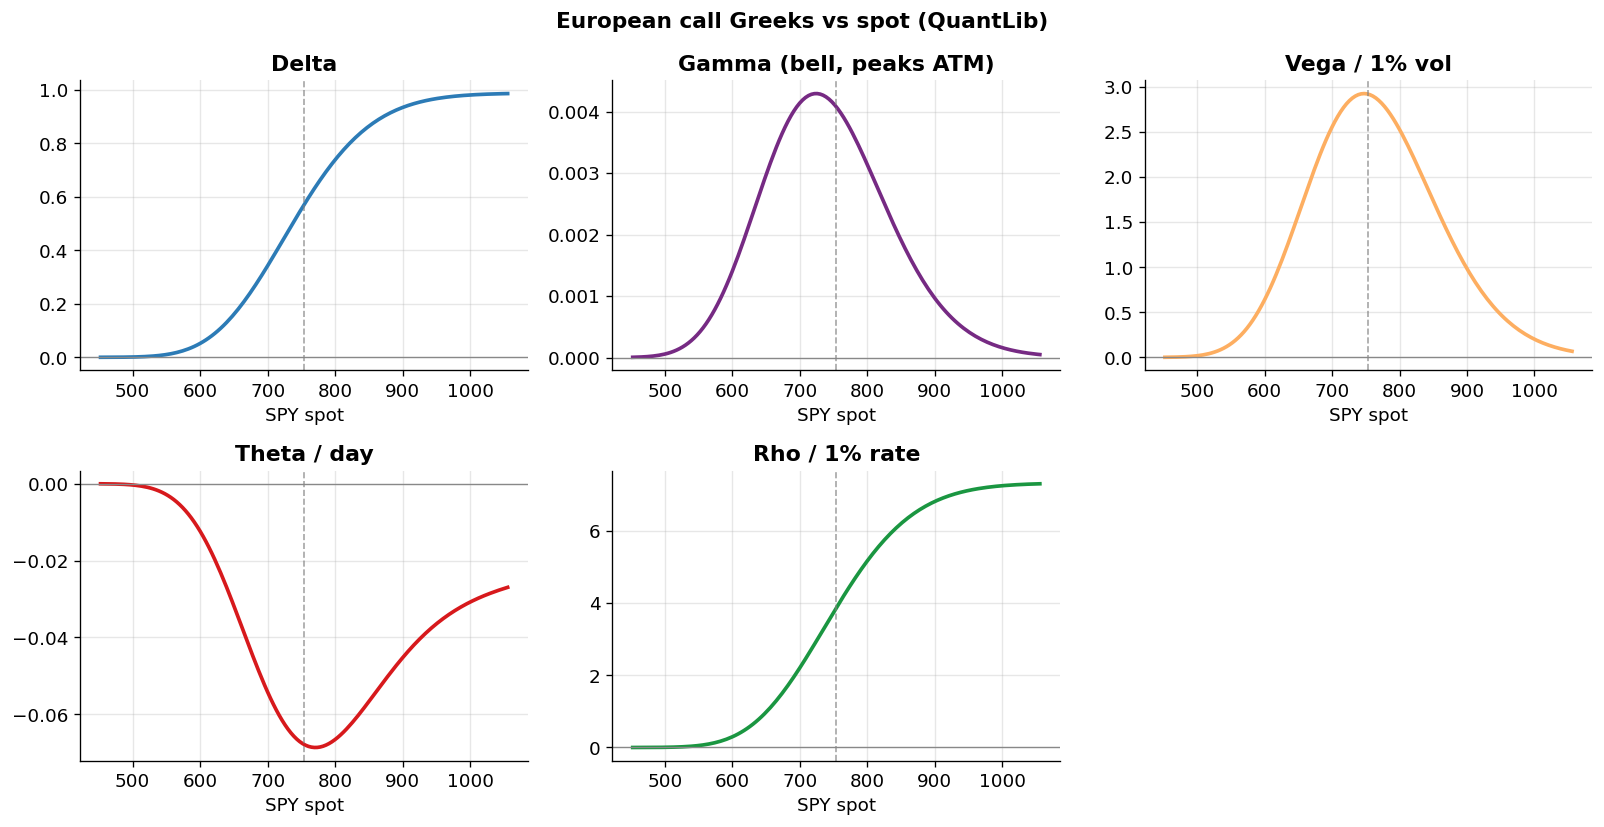

In [6]:
spots = np.linspace(S0*0.6, S0*1.4, 140)
g = {k: [] for k in ['delta','gamma','vega','theta','rho']}
for s in spots:
    spot_q.setValue(float(s))
    g['delta'].append(euro.delta()); g['gamma'].append(euro.gamma())
    g['vega'].append(euro.vega()/100); g['theta'].append(euro.thetaPerDay()); g['rho'].append(euro.rho()/100)
spot_q.setValue(S0)                                   # restore

specs = [('delta','Delta',BLUE), ('gamma','Gamma (bell, peaks ATM)',PUR), ('vega','Vega / 1% vol',GOLD),
         ('theta','Theta / day',RED), ('rho','Rho / 1% rate',GREEN)]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7)); axes = axes.ravel()
for ax, (k, title, col) in zip(axes, specs):
    ax.plot(spots, g[k], color=col, lw=2.2)
    ax.axvline(S0, color='grey', ls='--', lw=1, alpha=0.7)
    ax.axhline(0, color='#888', lw=0.8)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('SPY spot')
axes[-1].axis('off')
fig.suptitle('European call Greeks vs spot (QuantLib)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Part 5: The binomial tree converges to Black-Scholes

Swap the analytic engine for a **Cox-Ross-Rubinstein binomial engine** and watch the price settle onto
the closed-form value as the number of steps grows. This is the same convergence your from-scratch tree
shows, in one line per step count.

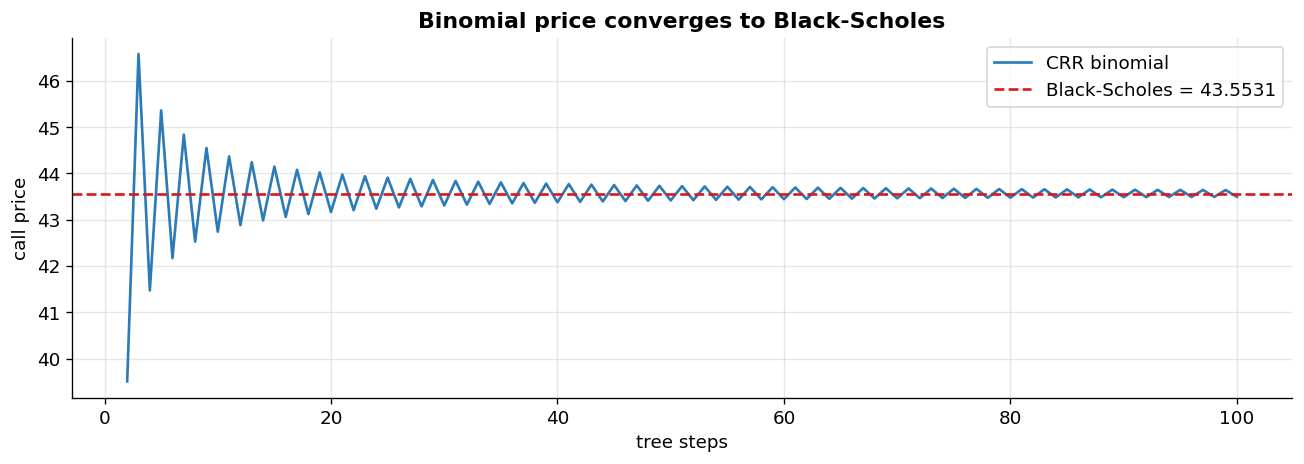

50-step tree 43.4169  vs  BS 43.5531


In [7]:
euro.setPricingEngine(ql.AnalyticEuropeanEngine(process)); bs_price = euro.NPV()
steps = list(range(2, 101))            # CRR engine needs at least 2 steps
tree_px = []
for n in steps:
    euro.setPricingEngine(ql.BinomialVanillaEngine(process, 'crr', n))
    tree_px.append(euro.NPV())
euro.setPricingEngine(ql.AnalyticEuropeanEngine(process))   # restore analytic

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(steps, tree_px, color=BLUE, lw=1.6, label='CRR binomial')
ax.axhline(bs_price, color=RED, lw=1.6, ls='--', label=f'Black-Scholes = {bs_price:.4f}')
ax.set_xlabel('tree steps'); ax.set_ylabel('call price'); ax.legend()
ax.set_title('Binomial price converges to Black-Scholes', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'50-step tree {tree_px[steps.index(50)]:.4f}  vs  BS {bs_price:.4f}')

## Part 6: American exercise and dividends (where the closed form stops)

A European option has one exercise date, so Black-Scholes has a formula. An **American** option can be
exercised any time, which has no simple closed form: you need a tree or a PDE. QuantLib just swaps the
exercise object. The gap between the American and European price is the **early-exercise premium**.

In [8]:
put_pay  = ql.PlainVanillaPayoff(ql.Option.Put, K)
eu_put   = ql.VanillaOption(put_pay, ql.EuropeanExercise(maturity))
eu_put.setPricingEngine(ql.AnalyticEuropeanEngine(process))
am_put   = ql.VanillaOption(put_pay, ql.AmericanExercise(today, maturity))
am_put.setPricingEngine(ql.BinomialVanillaEngine(process, 'crr', 600))

print(f'ATM PUT   K={K}   T={T:.2f}y')
print(f'  European {eu_put.NPV():.4f}')
print(f'  American {am_put.NPV():.4f}')
print(f'  early-exercise premium {am_put.NPV() - eu_put.NPV():.4f}')
print(f'  American delta {am_put.delta():.4f}  gamma {am_put.gamma():.5f}  (straight from the tree)')

ATM PUT   K=755   T=1.00y
  European 31.2136
  American 32.5895
  early-exercise premium 1.3759
  American delta -0.4434  gamma 0.00453  (straight from the tree)


**Dividends move calls and puts in opposite directions.** A higher dividend yield lowers the
forward, so it makes a call cheaper and a put dearer. We rebuild the process for each yield with a small
helper and plot it.

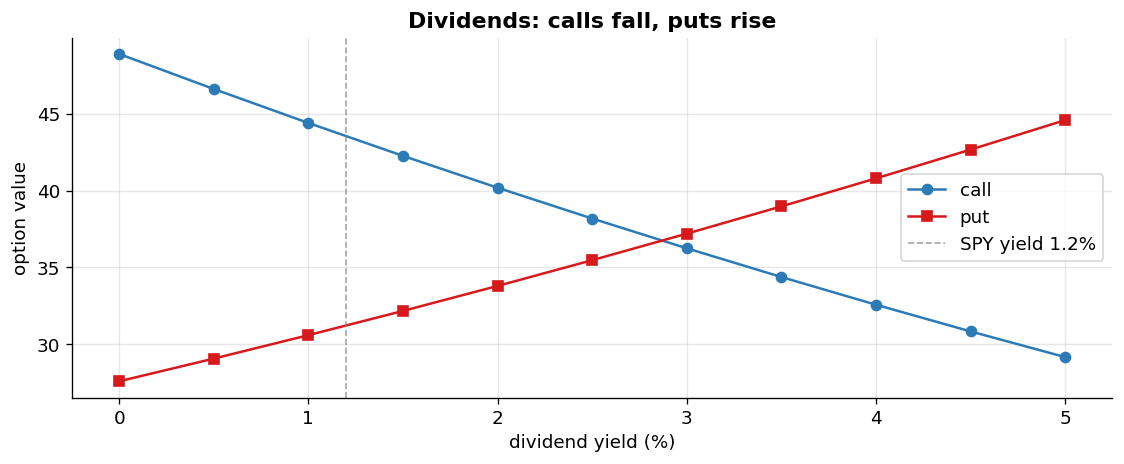

In [9]:
def make_process(S, r, q, sig):
    return ql.BlackScholesMertonProcess(
        ql.QuoteHandle(ql.SimpleQuote(S)),
        ql.YieldTermStructureHandle(ql.FlatForward(today, q, day_count)),
        ql.YieldTermStructureHandle(ql.FlatForward(today, r, day_count)),
        ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, calendar, sig, day_count)))

def price(cp, K, q_div, style='euro'):
    pay = ql.PlainVanillaPayoff(ql.Option.Call if cp == 'c' else ql.Option.Put, K)
    ex  = ql.EuropeanExercise(maturity) if style == 'euro' else ql.AmericanExercise(today, maturity)
    o   = ql.VanillaOption(pay, ex)
    proc = make_process(S0, r, q_div, sigma)
    o.setPricingEngine(ql.AnalyticEuropeanEngine(proc) if style == 'euro'
                       else ql.BinomialVanillaEngine(proc, 'crr', 400))
    return o.NPV()

qs = np.linspace(0.0, 0.05, 11)
calls = [price('c', K, qd) for qd in qs]
puts  = [price('p', K, qd) for qd in qs]
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(qs*100, calls, 'o-', color=BLUE, label='call')
ax.plot(qs*100, puts,  's-', color=RED,  label='put')
ax.axvline(div*100, color='grey', ls='--', lw=1, alpha=0.7, label=f'SPY yield {div:.1%}')
ax.set_xlabel('dividend yield (%)'); ax.set_ylabel('option value'); ax.legend()
ax.set_title('Dividends: calls fall, puts rise', fontweight='bold')
plt.tight_layout(); plt.show()

## Part 7: Implied volatility and the smile, from the real SPY chain

QuantLib inverts Black-Scholes for you with `impliedVolatility(...)`. We feed it real traded prices
from the cached SPY option chain and recover the implied vol at each strike. The result is the familiar
equity **skew**: downside puts price at a much higher vol than upside calls.

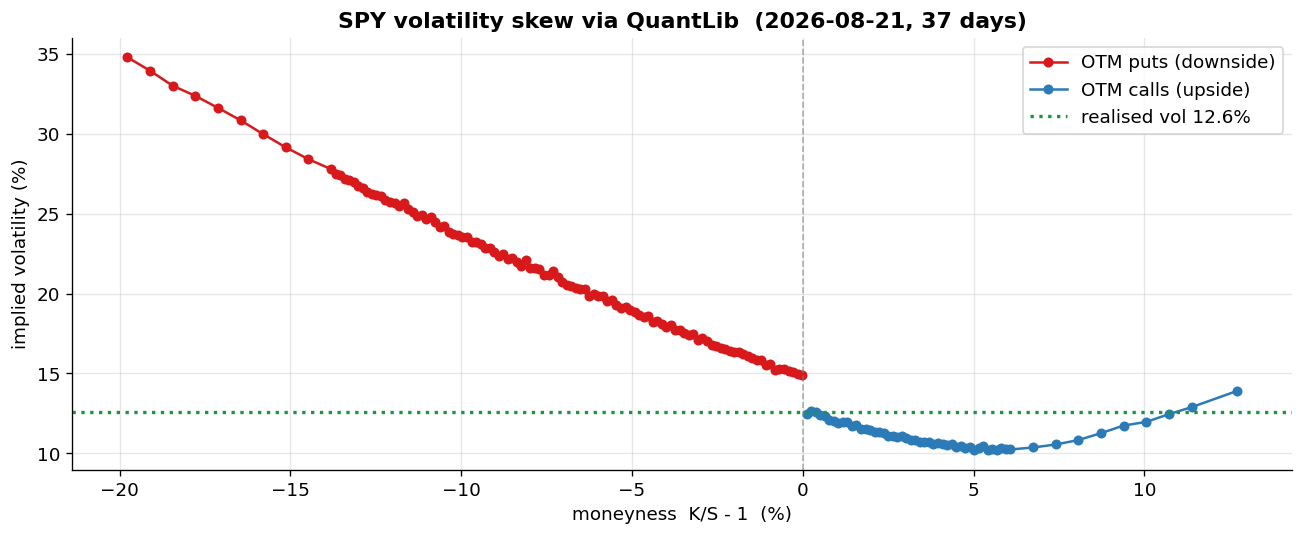

ATM implied vol 14.9%   |   deepest put IV 34.8%   |   lowest call IV 10.2%


In [10]:
ch = pd.read_csv(os.path.join(DATA, 'spy_option_chain.csv'))
csp   = float(ch['spot'].iloc[0])
casof = pd.to_datetime(ch['asof'].iloc[0].split()[0]).date()
ch['exp_date'] = pd.to_datetime(ch['expiry']).dt.date
ch['days'] = ch['exp_date'].apply(lambda d: (d - casof).days)
ch['mny']  = ch['strike'] / csp

# pick the listed expiry closest to 30 days, keep liquid OTM quotes
target = ch.loc[(ch['days'] - 30).abs().idxmin(), 'exp_date']
sub = ch[(ch['exp_date'] == target) & (ch['volume'] > 0) & (ch['lastPrice'] >= 0.05)
         & ((((ch['type'] == 'call') & (ch['strike'] >= csp)) |
             ((ch['type'] == 'put')  & (ch['strike'] <  csp)))) & ch['mny'].between(0.80, 1.20)].copy()

exp_ql = ql.Date(target.day, target.month, target.year)
def implied_vol(cp, strike, mkt_price):
    o = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Call if cp == 'call' else ql.Option.Put, strike),
                         ql.EuropeanExercise(exp_ql))
    proc = make_process(csp, 0.04, 0.0, 0.20)      # 0.20 is just a starting guess for the solver
    try:
        return o.impliedVolatility(mkt_price, proc, 1e-6, 500, 1e-4, 5.0)
    except RuntimeError:
        return np.nan

sub['iv'] = [implied_vol(t, k, p) for t, k, p in zip(sub['type'], sub['strike'], sub['lastPrice'])]
sub = sub.dropna(subset=['iv'])
sub = sub[sub['iv'].between(0.03, 1.5)].sort_values('strike')

fig, ax = plt.subplots(figsize=(11, 4.6))
puts  = sub[sub['type'] == 'put']; calls = sub[sub['type'] == 'call']
ax.plot((puts['mny']-1)*100,  puts['iv']*100,  'o-', color=RED,  ms=5, label='OTM puts (downside)')
ax.plot((calls['mny']-1)*100, calls['iv']*100, 'o-', color=BLUE, ms=5, label='OTM calls (upside)')
ax.axhline(sigma0*100, color=GREEN, ls=':', lw=2, label=f'realised vol {sigma0:.1%}')
ax.axvline(0, color='grey', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('moneyness  K/S - 1  (%)'); ax.set_ylabel('implied volatility (%)')
ax.set_title(f'SPY volatility skew via QuantLib  ({target}, {int(sub.days.iloc[0])} days)', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
atm = sub.loc[(sub['strike'] - csp).abs().idxmin()]
print(f'ATM implied vol {atm.iv:.1%}   |   deepest put IV {puts.iv.max():.1%}   |   lowest call IV {calls.iv.min():.1%}')

## Part 8: An exotic the closed form cannot touch

A **barrier option** knocks in or out if the spot touches a level. Here is an *up-and-out call*: it pays
like a call, but if SPY ever trades above the barrier the option dies (worth zero). QuantLib prices it
with a dedicated analytic engine; it is cheaper than the plain call because you give up the far upside.

In [11]:
barrier_level = round(S0 * 1.10 / 5) * 5
proc = make_process(S0, r, div, sigma)
vanilla = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Call, K), ql.EuropeanExercise(maturity))
vanilla.setPricingEngine(ql.AnalyticEuropeanEngine(proc))
uo = ql.BarrierOption(ql.Barrier.UpOut, barrier_level, 0.0,
                      ql.PlainVanillaPayoff(ql.Option.Call, K), ql.EuropeanExercise(maturity))
uo.setPricingEngine(ql.AnalyticBarrierEngine(proc))
print(f'Plain call            {vanilla.NPV():.4f}')
print(f'Up-and-out call (KO {barrier_level})   {uo.NPV():.4f}')
print(f'Discount for the knock-out   {vanilla.NPV() - uo.NPV():.4f}')
print('The up-and-out is cheaper: it pays nothing if SPY rallies through the barrier.')

Plain call            43.5531
Up-and-out call (KO 830)   2.9409
Discount for the knock-out   40.6122
The up-and-out is cheaper: it pays nothing if SPY rallies through the barrier.


## Summary: the QuantLib pattern and when to reach for it

Every pricing job above was the same six steps:

| Step | Object | Example |
|------|--------|---------|
| 1. quote | `SimpleQuote` | the spot price |
| 2. handle | `QuoteHandle`, `...TermStructureHandle` | a live pointer that auto-updates |
| 3. term structures | `FlatForward`, `BlackConstantVol` | rate curve, dividend curve, vol |
| 4. process | `BlackScholesMertonProcess` | bundles the dynamics |
| 5. engine | `AnalyticEuropeanEngine`, `BinomialVanillaEngine`, `AnalyticBarrierEngine` | the numerical method |
| 6. read | `.NPV()`, `.delta()`, `.gamma()`, `.impliedVolatility()` | price and Greeks |

**When to build it yourself (SciPy), when to use QuantLib.**
- Roll your own when the point is to *understand* the model, or the payoff is simple (vanilla European).
- Reach for QuantLib when you need American or exotic payoffs, real market conventions (calendars, day
  counts, holiday schedules), full yield-curve bootstrapping, or a battle-tested engine you can trust in
  production.

**Two gotchas to remember:** scale the Greeks yourself (vega and rho are per 1.00, theta is per year),
and QuantLib is date-driven, so a wrong evaluation date or day-count silently changes every number.

Related in this course: the from-scratch versions live in `Session_08_Derivatives_Notebook.ipynb`, and
the interactive versions are in `Session_08_Derivatives_Dashboard.html`.